In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
# ============================================================
# 1. LOAD DATASET
# ============================================================
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================================
# 2. SCALING (WAJIB UNTUK SVM)
# ============================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
# ============================================================
# 3. TUGAS 1 – BANDINKAN KERNEL LINEAR VS RBF
# ============================================================
print("=" * 60)
print("TUGAS 1: Perbandingan SVM Linear vs RBF")
print("=" * 60)

models = {
    "SVM Linear": SVC(kernel="linear", C=1),
    "SVM RBF": SVC(kernel="rbf", C=1, gamma="scale")
}

baseline_results = {}

for name, model in models.items():

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    baseline_results[name] = acc

    print(f"\n{name}")
    print("-" * 60)
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, pred, target_names=data.target_names))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))

TUGAS 1: Perbandingan SVM Linear vs RBF

SVM Linear
------------------------------------------------------------
Accuracy: 0.9561

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        43
      benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
[[41  2]
 [ 3 68]]

SVM RBF
------------------------------------------------------------
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
[[41  2]
 [ 0 71]]


In [4]:
# ============================================================
# 4. TUGAS 2 – TUNING MANUAL (C, gamma)
# ============================================================
print("\n" + "=" * 60)
print("TUGAS 2: Tuning Manual Parameter RBF")
print("=" * 60)

best_acc = 0
best_params = {}

for c_val in [0.1, 1, 10, 100]:
    for gamma_val in [0.001, 0.01, 0.1, 1]:
        model = SVC(kernel="rbf", C=c_val, gamma=gamma_val)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        print(f"C={c_val:<6} gamma={gamma_val:<6} → accuracy: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            best_params = {"C": c_val, "gamma": gamma_val}

print("\nParameter terbaik (Manual Tuning):")
print(best_params)
print(f"Accuracy terbaik: {best_acc:.4f}")


TUGAS 2: Tuning Manual Parameter RBF
C=0.1    gamma=0.001  → accuracy: 0.8070
C=0.1    gamma=0.01   → accuracy: 0.9649
C=0.1    gamma=0.1    → accuracy: 0.9474
C=0.1    gamma=1      → accuracy: 0.6228
C=1      gamma=0.001  → accuracy: 0.9649
C=1      gamma=0.01   → accuracy: 0.9649
C=1      gamma=0.1    → accuracy: 0.9649
C=1      gamma=1      → accuracy: 0.6316
C=10     gamma=0.001  → accuracy: 0.9825
C=10     gamma=0.01   → accuracy: 0.9825
C=10     gamma=0.1    → accuracy: 0.9649
C=10     gamma=1      → accuracy: 0.6316
C=100    gamma=0.001  → accuracy: 0.9825
C=100    gamma=0.01   → accuracy: 0.9561
C=100    gamma=0.1    → accuracy: 0.9649
C=100    gamma=1      → accuracy: 0.6316

Parameter terbaik (Manual Tuning):
{'C': 10, 'gamma': 0.001}
Accuracy terbaik: 0.9825


In [5]:
# ============================================================
# 5. GRIDSEARCH (TUNING OTOMATIS)
# ============================================================
print("\n" + "=" * 60)
print("GRID SEARCH CV")
print("=" * 60)

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
    "kernel": ["rbf"]
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters (GridSearch):", grid.best_params_)
print("Best Cross Validation Score:", round(grid.best_score_, 4))

best_model = grid.best_estimator_
final_pred = best_model.predict(X_test)
final_acc = accuracy_score(y_test, final_pred)

print("Test Accuracy setelah tuning:", round(final_acc, 4))


GRID SEARCH CV
Best Parameters (GridSearch): {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best Cross Validation Score: 0.9736
Test Accuracy setelah tuning: 0.9825



PERBANDINGAN HASIL
SVM Linear (baseline) : 0.9561
SVM RBF (baseline)    : 0.9825
SVM RBF (best tuned)  : 0.9825


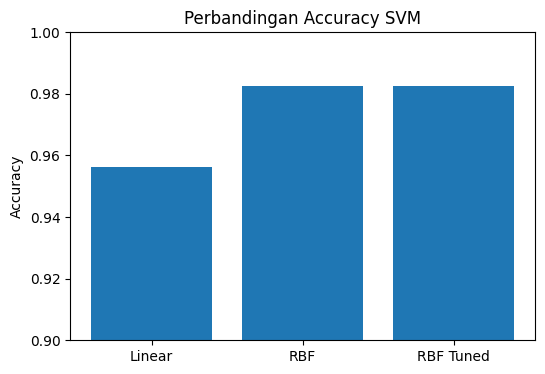

In [6]:
# ============================================================
# 6. PERBANDINGAN HASIL
# ============================================================
print("\n" + "=" * 60)
print("PERBANDINGAN HASIL")
print("=" * 60)

print(f"SVM Linear (baseline) : {baseline_results['SVM Linear']:.4f}")
print(f"SVM RBF (baseline)    : {baseline_results['SVM RBF']:.4f}")
print(f"SVM RBF (best tuned)  : {final_acc:.4f}")


# ============================================================
# 7. VISUALISASI PERBANDINGAN ACCURACY
# ============================================================
labels = ["Linear", "RBF", "RBF Tuned"]
values = [
    baseline_results["SVM Linear"],
    baseline_results["SVM RBF"],
    final_acc
]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title("Perbandingan Accuracy SVM")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)
plt.show()


In [7]:
# ============================================================
# 8. TUGAS 3 – 3 POIN KESIMPULAN
# ============================================================
print("\n" + "=" * 60)
print("KESIMPULAN")
print("=" * 60)

print("1. Kernel RBF memberikan performa lebih baik dibandingkan kernel Linear")
print("   karena mampu menangkap pola non-linear pada dataset Breast Cancer.")
print("2. Parameter C dan gamma sangat mempengaruhi performa model.")
print("   Nilai C besar meningkatkan kompleksitas model, sedangkan gamma")
print("   mengontrol jangkauan pengaruh tiap titik data.")
print("3. Tuning menggunakan GridSearchCV meningkatkan performa dibandingkan")
print("   parameter default. Selain itu, scaling fitur sangat wajib dilakukan")
print("   sebelum menggunakan SVM.")

print("\n✅ Pertemuan 05 selesai.")


KESIMPULAN
1. Kernel RBF memberikan performa lebih baik dibandingkan kernel Linear
   karena mampu menangkap pola non-linear pada dataset Breast Cancer.
2. Parameter C dan gamma sangat mempengaruhi performa model.
   Nilai C besar meningkatkan kompleksitas model, sedangkan gamma
   mengontrol jangkauan pengaruh tiap titik data.
3. Tuning menggunakan GridSearchCV meningkatkan performa dibandingkan
   parameter default. Selain itu, scaling fitur sangat wajib dilakukan
   sebelum menggunakan SVM.

✅ Pertemuan 05 selesai.
